In [171]:
import bars
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [172]:
import importlib
importlib.reload(bars)

[2025/03/03 16:51:15] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='C:\\Users\\admin/.paddleocr/whl\\det\\en\\en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='C:\\Users\\admin/.paddleocr/whl\\rec\\en\\en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=

<module 'bars' from 'd:\\Projects\\ChartInsight\\utils\\bars.py'>

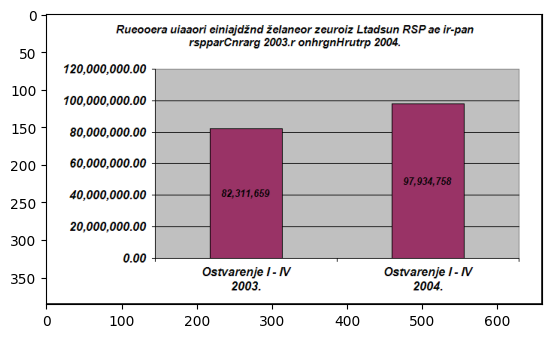

In [173]:
image_path = "./../assets/dataset/reduced_data/bardata(1031)/bar/images/train2019/013643546a25fd94fa9345a763b83304_d3d3Lmdvdi5tZQkxOTUuNjYuMTY2Ljgx.xls-0-0.png"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)

In [174]:
filtered = bars.detect_objects(bars.od_model, image, 4)
filtered


0: 384x640 1 ChartTitle, 1 PlotArea, 1 InnerPlotArea, 18.2ms
Speed: 2.7ms preprocess, 18.2ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


array([     21.029,      62.016,         631,      374.04,     0.96198,           4], dtype=float32)


image 1/1 d:\Projects\ChartInsight\utils\..\assets\dataset\reduced_data\bardata(1031)\bar\images\train2019\013643546a25fd94fa9345a763b83304_d3d3Lmdvdi5tZQkxOTUuNjYuMTY2Ljgx.xls-0-0.png: 384x640 1 ChartTitle, 1 PlotArea, 1 InnerPlotArea, 17.1ms
Speed: 1.5ms preprocess, 17.1ms inference, 2.7ms postprocess per image at shape (1, 3, 384, 640)


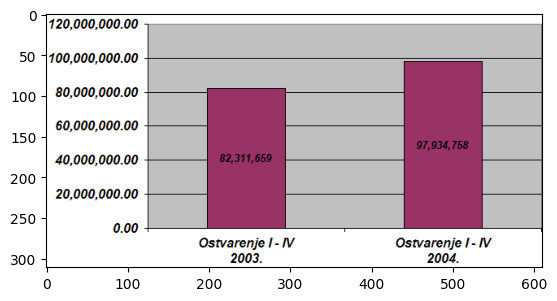

In [175]:
plot_area = bars.get_plot_area(image_path)
plt.imshow(plot_area)

In [176]:
bar_anns = bars.get_bar_anns(plot_area)
bar_anns


0: 352x640 2 Seriess, 18.1ms
Speed: 2.5ms preprocess, 18.1ms inference, 2.5ms postprocess per image at shape (1, 3, 352, 640)


array([[     441.95,      57.163,      536.12,      259.67,     0.97729,           0],
       [     199.39,      87.938,      294.06,      263.08,     0.95832,           0]], dtype=float32)

In [177]:
ocr_results = bars.get_ocr_results(plot_area)
ocr_results

[2025/03/03 16:51:18] ppocr DEBUG: dt_boxes num : 13, elapsed : 0.05307626724243164
[2025/03/03 16:51:18] ppocr DEBUG: cls num  : 13, elapsed : 0.03404498100280762
[2025/03/03 16:51:18] ppocr DEBUG: rec_res num  : 13, elapsed : 0.5864436626434326


[[[[[3.0, 4.0], [114.0, 4.0], [114.0, 20.0], [3.0, 20.0]],
   ('120,000,000.00', 0.9987020492553711)],
  [[[3.0, 46.0], [114.0, 46.0], [114.0, 62.0], [3.0, 62.0]],
   ('100,000,000.00', 0.9981475472450256)],
  [[[12.0, 89.0], [113.0, 89.0], [113.0, 103.0], [12.0, 103.0]],
   ('80,000,000.00', 0.9913462996482849)],
  [[[11.0, 128.0], [114.0, 128.0], [114.0, 145.0], [11.0, 145.0]],
   ('60,000,000.00', 0.9966716170310974)],
  [[[453.0, 154.0], [521.0, 154.0], [521.0, 167.0], [453.0, 167.0]],
   ('97,934,758', 0.9940093159675598)],
  [[[12.0, 172.0], [113.0, 172.0], [113.0, 186.0], [12.0, 186.0]],
   ('40,000,000.00', 0.9950435161590576)],
  [[[213.0, 170.0], [279.0, 170.0], [279.0, 184.0], [213.0, 184.0]],
   ('82,311, 659', 0.9644161462783813)],
  [[[11.0, 213.0], [114.0, 213.0], [114.0, 229.0], [11.0, 229.0]],
   ('20,000,000.00', 0.9969272017478943)],
  [[[80.0, 255.0], [119.0, 255.0], [119.0, 272.0], [80.0, 272.0]],
   ('0.00', 0.9997192025184631)],
  [[[189.0, 272.0], [306.0, 272.0]

In [178]:
x_labels = bars.merge_x_labels(bars.filter_axis_labels(ocr_results, 50, axis='x'))
y_labels = bars.filter_axis_labels(ocr_results, 100, axis='y')

print(x_labels)
print(y_labels)

[{'text': 'Ostvarenje I - IV 2003.', 'conf': 0.9999328851699829, 'x_mean': 246.0, 'y_mean': 299.5}, {'text': 'Ostvarenje I- IV 2004.', 'conf': 0.9999359846115112, 'x_mean': 488.0, 'y_mean': 299.5}]
[{'text': '120,000,000.00', 'conf': 0.9987020492553711, 'x_mean': 58.5, 'y_mean': 12.0}, {'text': '100,000,000.00', 'conf': 0.9981475472450256, 'x_mean': 58.5, 'y_mean': 54.0}, {'text': '80,000,000.00', 'conf': 0.9913462996482849, 'x_mean': 62.5, 'y_mean': 96.0}, {'text': '60,000,000.00', 'conf': 0.9966716170310974, 'x_mean': 62.5, 'y_mean': 136.5}, {'text': '40,000,000.00', 'conf': 0.9950435161590576, 'x_mean': 62.5, 'y_mean': 179.0}, {'text': '20,000,000.00', 'conf': 0.9969272017478943, 'x_mean': 62.5, 'y_mean': 221.0}, {'text': '0.00', 'conf': 0.9997192025184631, 'x_mean': 99.5, 'y_mean': 263.5}]


In [179]:
bar_info = bars.get_bar_values(bar_anns, x_labels, y_labels)
bar_info

[{'bbox': array([     199.39,      87.938,      294.06,      263.08], dtype=float32),
  'label': 'Ostvarenje I - IV 2003.',
  'value': 83767184.49071197},
 {'bbox': array([     441.95,      57.163,      536.12,      259.67], dtype=float32),
  'label': 'Ostvarenje I- IV 2004.',
  'value': 98451260.2121645}]

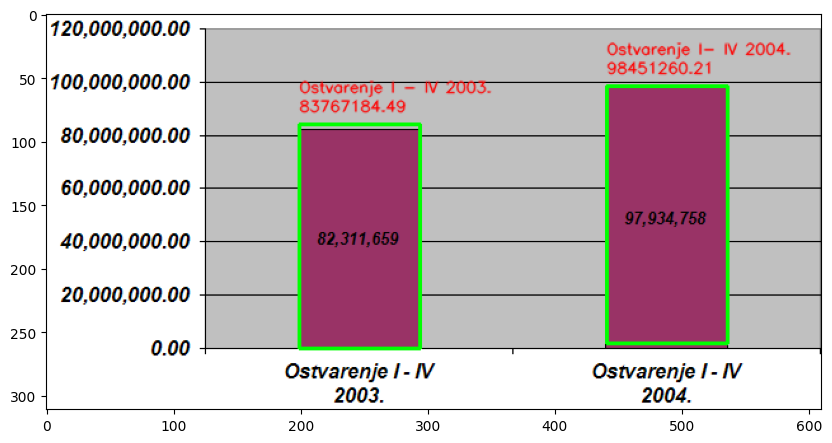

In [180]:
# plot the bars 
plot_area_copy = plot_area.copy()

for bar in bar_info:
    x1, y1, x2, y2 = map(int, bar['bbox'])

    cv2.rectangle(plot_area_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)

    text_x = x1
    text_y = y1 - 10 

    cv2.putText(plot_area_copy, bar['label'], (text_x, text_y - 15),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1, cv2.LINE_AA)

    value_text = f"{bar['value']:.2f}"
    cv2.putText(plot_area_copy, value_text, (text_x, text_y),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1, cv2.LINE_AA)

plt.figure(figsize=(10, 8))
plt.imshow(plot_area_copy)
plt.show()